# 1. Import library

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, f1_score

import warnings
warnings.filterwarnings('ignore')

print("Cell 1: Semua Library Berhasil Dimuat!")


Cell 1: Semua Library Berhasil Dimuat!


# 2. Load dataset

In [17]:
file_path = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv' 
train_df = pd.read_csv(file_path)

print("Dataset Telco Churn Berhasil Dimuat!")
print(f"Dimensi Data: {train_df.shape[0]} Baris, {train_df.shape[1]} Kolom")
print(f"\nDistribusi Target:\n{train_df['Churn'].value_counts()}")
print(f"\nPersentase Churn:\n{train_df['Churn'].value_counts(normalize=True)*100}")

Dataset Telco Churn Berhasil Dimuat!
Dimensi Data: 7043 Baris, 21 Kolom

Distribusi Target:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# 3. Ambil feature & label

In [18]:
# Drop ID karena tidak relevan untuk ML
train_df = train_df.drop(columns=['customerID'])

# Memisahkan X dan y
X = train_df.drop(columns=['Churn'])
y = train_df['Churn'].map({'Yes': 1, 'No': 0}) # Ubah ke angka untuk evaluasi

print("Feature (X) dan Label (y) Berhasil Dipisahkan!")
print(f"Dimensi Feature (X): {X.shape[0]} Baris, {X.shape[1]} Kolom")
print(f"Dimensi Label (y): {y.shape[0]} Baris")

Feature (X) dan Label (y) Berhasil Dipisahkan!
Dimensi Feature (X): 7043 Baris, 19 Kolom
Dimensi Label (y): 7043 Baris


# 4. Split dataset

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset Berhasil Di-split (80% Train, 20% Test)!")
print(f"Dimensi X_train: {X_train.shape[0]} Baris")
print(f"Dimensi X_test: {X_test.shape[0]} Baris")

Dataset Berhasil Di-split (80% Train, 20% Test)!
Dimensi X_train: 5634 Baris
Dimensi X_test: 1409 Baris


# 5. Preprocessing

In [20]:
# 1. Handling Missing Values di TotalCharges (Ubah spasi jadi NaN, lalu isi median)
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')

median_val = X_train['TotalCharges'].median()
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(median_val)
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(median_val)

# 2. Encoding (One-Hot Encoding untuk data teks)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Menyamakan kolom jika ada kategori yang hilang saat di-split
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 3. Scaling (Wajib ada untuk SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Preprocessing Selesai!")
print("✓ Handling Missing Values (TotalCharges diisi median)")
print("✓ Encoding Kategorikal (One-Hot Encoding)")
print("✓ Scaling Data (StandardScaler)")
print(f"Dimensi X_train_scaled: {X_train_scaled.shape[0]} Baris, {X_train_scaled.shape[1]} Kolom")

Preprocessing Selesai!
✓ Handling Missing Values (TotalCharges diisi median)
✓ Encoding Kategorikal (One-Hot Encoding)
✓ Scaling Data (StandardScaler)
Dimensi X_train_scaled: 5634 Baris, 30 Kolom


# 6. SMOTE + classifier

In [21]:
# Menerapkan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Melatih Classifier SVM Base (Sebagai perbandingan awal)
svm_base = SVC(random_state=42)
svm_base.fit(X_train_smote, y_train_smote)

print("SMOTE Berhasil Diterapkan!")
print(f"Distribusi Target Sesudah SMOTE:\n{y_train_smote.value_counts()}")
print("\nClassifier SVM (Base Model) Berhasil Dilatih dengan Data SMOTE!")

SMOTE Berhasil Diterapkan!
Distribusi Target Sesudah SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64

Classifier SVM (Base Model) Berhasil Dilatih dengan Data SMOTE!


# 7. Training + GridSearchCV (HPO)

In [22]:
import time
print("Memulai Hyperparameter Optimization (GridSearchCV)...")
start_time = time.time()

# Kita batasi grid-nya sedikit agar tidak hang (hapus C=10 karena biasanya komputasi C besar sangat lama di SVM)
param_grid = {
    'C': [0.1, 1], 
    'kernel': ['linear', 'rbf']
}

# RAHASIA KECEPATAN: probability=True KITA HAPUS DULU DI SINI
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Mulai pencarian parameter (Ini mungkin butuh 1-3 menit, ditunggu saja ya)
grid_search.fit(X_train_smote, y_train_smote)

print(f"Training HPO Selesai dalam {(time.time() - start_time)/60:.2f} menit!")
print(f"Parameter SVM Terbaik: {grid_search.best_params_}")

# Latih ulang 1x model final MENGGUNAKAN probability=True untuk kebutuhan UI
print("\nMelatih ulang model final dengan parameter terbaik untuk Web UI...")
best_params = grid_search.best_params_
best_svm = SVC(**best_params, probability=True, random_state=42)
best_svm.fit(X_train_smote, y_train_smote)

print("Model Final (best_svm) Siap Digunakan!")

Memulai Hyperparameter Optimization (GridSearchCV)...
Training HPO Selesai dalam 0.14 menit!
Parameter SVM Terbaik: {'C': 1, 'kernel': 'rbf'}

Melatih ulang model final dengan parameter terbaik untuk Web UI...
Model Final (best_svm) Siap Digunakan!


# 8. Akurasi + threshold

In [8]:
# Prediksi Data Mentah (Imbalanced) untuk perbandingan dosen
svm_imbalanced = SVC(random_state=42).fit(X_train_scaled, y_train)
y_pred_imb = svm_imbalanced.predict(X_test_scaled)
acc_imb = accuracy_score(y_test, y_pred_imb)

# Prediksi Data Balanced (SMOTE + HPO)
y_pred_final = best_svm.predict(X_test_scaled)
acc_final = accuracy_score(y_test, y_pred_final)

print("=== HASIL AKURASI MODEL ===")
print(f"Akurasi Model Data Mentah (Imbalanced): {acc_imb * 100:.2f}%")
print(f"Akurasi Model Final (SMOTE + HPO): {acc_final * 100:.2f}%")

=== HASIL AKURASI MODEL ===
Akurasi Model Data Mentah (Imbalanced): 79.28%
Akurasi Model Final (SMOTE + HPO): 75.73%


# 9. Confusion matrix

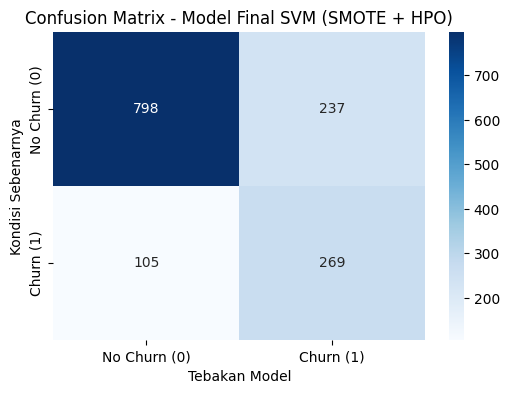

In [9]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Model Final SVM (SMOTE + HPO)')
plt.ylabel('Kondisi Sebenarnya')
plt.xlabel('Tebakan Model')
plt.show()

# 10. Detail perbandingan

In [10]:
print("=== DETAIL PERBANDINGAN (CLASSIFICATION REPORT) ===")
print("1. HASIL MODEL MENTAH (IMBALANCED)")
print(classification_report(y_test, y_pred_imb))

print("-" * 55)

print("2. HASIL MODEL FINAL (SMOTE + HPO)")
print(classification_report(y_test, y_pred_final))

=== DETAIL PERBANDINGAN (CLASSIFICATION REPORT) ===
1. HASIL MODEL MENTAH (IMBALANCED)
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

-------------------------------------------------------
2. HASIL MODEL FINAL (SMOTE + HPO)
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



# 11. Simpan model

In [28]:
import os
import json
import joblib
from sklearn.metrics import roc_auc_score, f1_score

os.makedirs('../models', exist_ok=True)

# ── Simpan Model & Preprocessor ──────────────────────────────────────────────
joblib.dump(best_svm,              '../models/svm_model.pkl')
joblib.dump(scaler,                '../models/svm_scaler.pkl')

feature_names = X_train_encoded.columns.tolist()
joblib.dump(feature_names,         '../models/svm_feature_names.pkl')

# ── Simpan Best Params ────────────────────────────────────────────────────────
with open('../models/best_params_svm.json', 'w') as f:
    json.dump({
        'C'          : best_params['C'],
        'kernel'     : best_params['kernel'],
        'probability': True,
        'random_state': 42
    }, f, indent=2)

# ── Hitung Metrik Evaluasi ────────────────────────────────────────────────────
y_proba_svm  = best_svm.predict_proba(X_test_scaled)[:, 1]
auc_score    = roc_auc_score(y_test, y_proba_svm)

# Cari threshold terbaik berdasarkan Macro F1
thresholds   = [round(t, 2) for t in sorted(set(y_proba_svm))]
best_thresh  = max(thresholds, key=lambda t: f1_score(y_test, (y_proba_svm >= t).astype(int), average='macro'))
best_f1      = f1_score(y_test, (y_proba_svm >= best_thresh).astype(int), average='macro')

# ── Simpan Metadata Model ─────────────────────────────────────────────────────
joblib.dump({
    'n_features'   : X_train_encoded.shape[1],
    'feature_names': feature_names,
    'model_version': 'SVM+SMOTE+HPO+Telco',
    'auc'          : round(auc_score, 4),
    'macro_f1'     : round(best_f1, 4),
    'threshold'    : round(best_thresh, 2)
}, '../models/svm_model_metadata.pkl')

# ── Ringkasan ─────────────────────────────────────────────────────────────────
print("✅ Model SVM Final Tersimpan!")
print(f"AUC       : {auc_score:.4f}")
print(f"Macro F1  : {best_f1:.4f}")
print(f"Threshold : {best_thresh:.2f}")
print("Files:", os.listdir('../models'))

✅ Model SVM Final Tersimpan!
AUC       : 0.8164
Macro F1  : 0.7274
Threshold : 0.63
Files: ['best_params_dt.json', 'best_params_knn_telco.json', 'best_params_rf.json', 'best_params_svm.json', 'decision_tree_model.pkl', 'dt_metadata.pkl', 'dt_model.pkl', 'dt_preprocessor.pkl', 'dt_selected_features.pkl', 'knn_model.pkl', 'knn_preprocessor.pkl', 'knn_selected_features.pkl', 'model_metadata.pkl', 'rf_label_encoders.pkl', 'rf_model.pkl', 'rf_scaler.pkl', 'selected_features.pkl', 'svm_feature_names.pkl', 'svm_model.pkl', 'svm_model_metadata.pkl', 'svm_scaler.pkl', 'svm_selected_features.pkl', 'X_columns.pkl']


# 12. Sanity check

In [ ]:
sample       = X_test_scaled[:5]
proba_sample = best_svm.predict_proba(sample)[:, 1]
pred_sample  = (proba_sample >= best_thresh).astype(int)

result = pd.DataFrame({
    'Actual'     : y_test.iloc[:5].values,
    'Predicted'  : pred_sample,
    'Prob(Churn)': proba_sample.round(3)
})
print("=== SANITY CHECK ===")
print(result)

=== SANITY CHECK ===
   Actual  Predicted  Prob(Churn)
0       0          0        0.073
1       0          1        0.863
2       0          0        0.064
3       0          0        0.425
4       0          0        0.075
